# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


In [0]:
# Initialize the random number generator
import random
random.seed(0)

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [3]:
from keras.backend import backend
from keras.datasets import cifar10

# the data, shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

Using TensorFlow backend.


Label: [9]


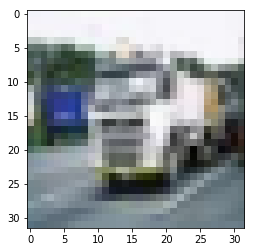

In [4]:
# X_train and X_test contain greyscale RGB codes (from 0 to 255) while y_train and y_test contains labels from 0 to 9 which represents which number they actually are.

# Let's visualize some numbers using matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
print("Label: {}".format(y_train[1000]))
plt.imshow(X_train[1000], cmap='gray')


In [5]:
'''cifar10_labels = [ "zero",  # index 0
                 "one",   # index 1
                 "two",   # index 2 
                 "three",   # index 3 
                 "four",    # index 4
                 "five",    # index 5
                 "six",     # index 6 
                 "seven",   # index 7 
                 "eight",   # index 8 
                 "nine"]   # index 9'''

'cifar10_labels = [ "zero",  # index 0\n                 "one",   # index 1\n                 "two",   # index 2 \n                 "three",   # index 3 \n                 "four",    # index 4\n                 "five",    # index 5\n                 "six",     # index 6 \n                 "seven",   # index 7 \n                 "eight",   # index 8 \n                 "nine"]   # index 9'

In [0]:
def plot_images(image_label_tuple, grid_nums):
    plt.figure(figsize=(2*grid_nums, 2*grid_nums))
    for i in range(grid_nums**2):
        plt.subplot(grid_nums, grid_nums, i+1)
        plt.imshow(image_label_tuple[0][i], cmap='gray')
        plt.colorbar()
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(image_label_tuple[1][i])
        plt.grid(False)
    plt.show()

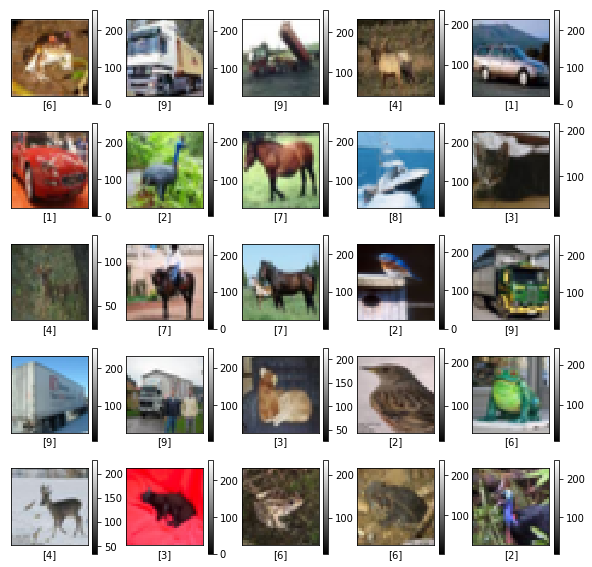

In [7]:
plot_images((X_train, y_train),5)

In [8]:
print(X_train.shape)
print(y_train.dtype)
print(X_test.shape)
print(y_test.dtype)
y_train

(50000, 32, 32, 3)
uint8
(10000, 32, 32, 3)
int64


array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [0]:
#

Train: X=(50000, 32, 32, 3), y=(50000, 1)
Test: X=(10000, 32, 32, 3), y=(10000, 1)


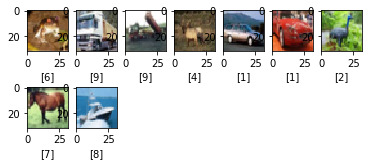

In [10]:
from matplotlib import pyplot
print('Train: X=%s, y=%s' % (X_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (X_test.shape, y_test.shape))
# plot first few images
for i in range(9):
    # define subplot
    pyplot.subplot(370 + 1 + i)
    # plot raw pixel data
    pyplot.imshow(X_train[i])
    pyplot.xlabel(y_train[i])
# show the figure
pyplot.show()

In [0]:
train_images_0_4 = np.array([X_train[i] for i, x in enumerate(y_train) if x < 5])
test_images_0_4 = np.array([X_test[i] for i, x in enumerate(y_test) if x < 5])
train_labels_0_4 = np.array([y_train[i] for i, x in enumerate(y_train) if x < 5])
test_labels_0_4 = np.array([y_test[i] for i, x in enumerate(y_test) if x < 5])

In [0]:
train_images_5_9 = np.array([X_train[i] for i, x in enumerate(y_train) if x >= 5])
test_images_5_9 = np.array([X_test[i] for i, x in enumerate(y_test) if x >= 5])
train_labels_5_9 = np.array([y_train[i] for i, x in enumerate(y_train) if x >= 5])
test_labels_5_9 = np.array([y_test[i] for i, x in enumerate(y_test) if x >= 5])

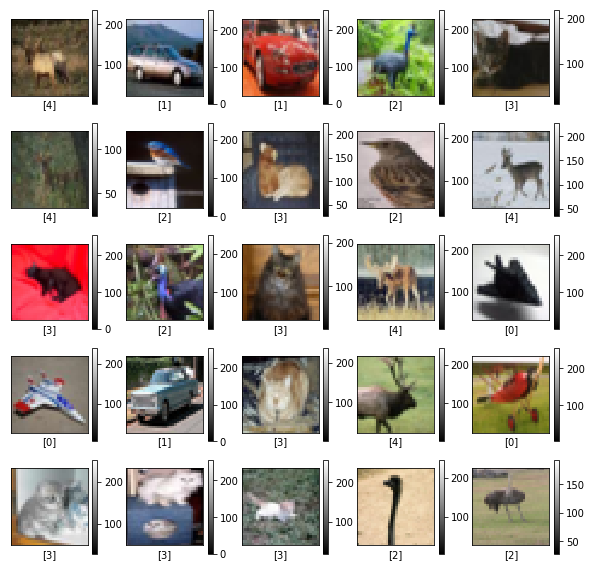

In [13]:
plot_images((train_images_0_4, train_labels_0_4),5)

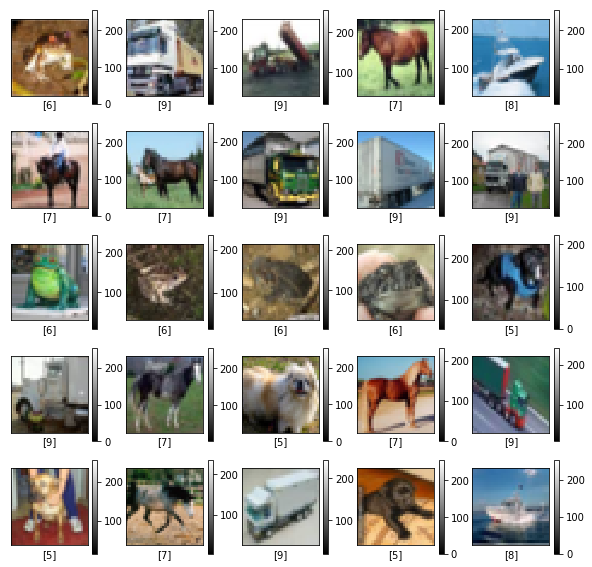

In [14]:
plot_images((train_images_5_9, train_labels_5_9),5)

In [22]:
print(train_images_0_4.shape)
print(train_labels_0_4.dtype)
print(test_images_0_4.shape)
print(test_labels_0_4.dtype)
print(train_images_5_9.shape)
print(train_labels_5_9.dtype)
print(test_images_5_9.shape)
print(test_labels_5_9.dtype)

(25000, 32, 32, 3)
uint8
(5000, 32, 32, 3)
int64
(25000, 32, 32, 3)
uint8
(5000, 32, 32, 3)
int64


### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [0]:
import tensorflow as tf
tf.reset_default_graph()
tf.set_random_seed(42)

In [27]:
# tf.keras.utils.normalize(x_train_images_0_4, axis=-1, order=2)

array([[[[0.72079773, 0.6435694 , 0.25742776],
         [0.68873723, 0.63289367, 0.35367588],
         [0.68593846, 0.63178542, 0.36102024],
         ...,
         [0.70005212, 0.61715121, 0.35923727],
         [0.69472253, 0.61753114, 0.36880332],
         [0.68921436, 0.61623872, 0.381095  ]],

        [[0.73027439, 0.61962676, 0.28768385],
         [0.71646458, 0.63217463, 0.29501483],
         [0.73471061, 0.61991208, 0.27551648],
         ...,
         [0.69333831, 0.59846044, 0.40140639],
         [0.69506845, 0.5937043 , 0.4054566 ],
         [0.70749858, 0.59929292, 0.37455807]],

        [[0.74101112, 0.60800912, 0.28500428],
         [0.73298932, 0.60471619, 0.31152046],
         [0.68930322, 0.60465195, 0.39907029],
         ...,
         [0.71058649, 0.58069433, 0.39731718],
         [0.69465876, 0.57780027, 0.4284811 ],
         [0.71065911, 0.57600791, 0.4039536 ]],

        ...,

        [[0.67946106, 0.59759828, 0.42568645],
         [0.6745605 , 0.59702481, 0.43419986]

In [0]:
# tf.keras.backend.clear_session()
#Initialize model, reshape & normalize data
# x_train_images_0_4=train_images_0_4 #.reshape((25000, 32, 32,3))
# x_test_images_0_4=test_images_0_4 #.reshape((5000, 32, 32,3))
# model = tf.keras.models.Sequential()

In [0]:
x_train_images_0_4 = tf.keras.utils.normalize(x_train_images_0_4, axis=-1, order=2)
x_test_images_0_4 = tf.keras.utils.normalize(test_images_0_4, axis=-1, order=2)
# x_train_images_0_4 = tf.nn.l2_normalize(train_images_0_4.shape,1)
# x_train_images_5_9 = tf.nn.l2_normalize(train_images_5_9.shape,1)
# x_test_images_0_4 = tf.nn.l2_normalize(test_images_0_4.shape,1)
# x_test_images_5_9 = tf.nn.l2_normalize(test_images_5_9.shape,1)

In [29]:
print(x_train_images_0_4.shape)
print(x_train_images_0_4.shape[0])
print(x_test_images_0_4.shape[0])

(25000, 32, 32, 3)
25000
5000


In [0]:
y_train_labels_0_4 = tf.keras.utils.to_categorical(train_labels_0_4, num_classes=5)
y_test_labels_0_4 = tf.keras.utils.to_categorical(test_labels_0_4, num_classes=5)

### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [0]:
model = tf.keras.models.Sequential()
#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu',input_shape=(32,32,3)))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))

#Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

#Add another dropout layer
model.add(tf.keras.layers.Dropout(0.2))

In [0]:
#Flatten the output
model.add(tf.keras.layers.Flatten())

#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model.add(tf.keras.layers.Dense(5, activation='softmax'))
#model.add(tf.keras.layers.Activation('softmax'))

In [0]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [42]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 14, 14, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 6272)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               802944    
_________________________________________________________________
dense_3 (Dense)              (None, 5)                

In [43]:
chpt = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')
#Train the model
model.fit(x_train_images_0_4,y_train_labels_0_4,epochs=10,batch_size=128, callbacks=[chpt] )

Epoch 1/10
25000/25000 [==============================] - 57s 2ms/sample - loss: 1.1379 - acc: 0.5519
Epoch 2/10
25000/25000 [==============================] - 58s 2ms/sample - loss: 0.9889 - acc: 0.6147
Epoch 3/10
25000/25000 [==============================] - 58s 2ms/sample - loss: 0.9182 - acc: 0.6465
Epoch 4/10
25000/25000 [==============================] - 57s 2ms/sample - loss: 0.8595 - acc: 0.6711
Epoch 5/10
25000/25000 [==============================] - 57s 2ms/sample - loss: 0.8087 - acc: 0.6907
Epoch 6/10
25000/25000 [==============================] - 57s 2ms/sample - loss: 0.7621 - acc: 0.7047
Epoch 7/10
25000/25000 [==============================] - 57s 2ms/sample - loss: 0.7124 - acc: 0.7262
Epoch 8/10
25000/25000 [==============================] - 58s 2ms/sample - loss: 0.6538 - acc: 0.7522
Epoch 9/10
25000/25000 [==============================] - 58s 2ms/sample - loss: 0.6119 - acc: 0.7650
Epoch 10/10
25000/25000 [==============================] - 58s 2ms/sample - loss: 

In [44]:
score=model.evaluate(x_test_images_0_4,y_test_labels_0_4)
score[1]

5000/5000 [==============================] - 3s 632us/sample - loss: 0.9018 - acc: 0.6792


0.6792

### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [45]:
model.save('cifar10_0_4.h5')
Model = tf.keras.models.load_model('cifar10_0_4.h5')
#Set pre-trained model layers to not trainable
for layer in Model.layers:
  if 'dense' in layer.name:
    layer.trainable = True
  else:
    layer.trainable =False

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

In [0]:
y_train_labels_5_9 = train_labels_5_9 -5
y_test_labels_5_9 = test_labels_5_9 - 5

In [47]:
#Initialize model, reshape & normalize data
x_train_images_5_9=train_images_5_9.reshape((train_images_5_9.shape[0], 32, 32,3))
x_test_images_5_9=test_images_5_9.reshape((test_images_5_9.shape[0], 32, 32,3))
print(x_train_images_5_9.shape)
print(x_test_images_5_9.shape)

(25000, 32, 32, 3)
(5000, 32, 32, 3)


In [49]:
# Normalize Images
x_train_images_5_9 = tf.keras.utils.normalize(train_images_5_9, axis=-1, order=2)
x_test_images_5_9 = tf.keras.utils.normalize(test_images_5_9, axis=-1, order=2)
print(x_train_images_5_9.shape)
print(x_test_images_5_9.shape)
print(x_train_images_5_9.shape[0])
print(x_test_images_5_9.shape[0])

(25000, 32, 32, 3)
(5000, 32, 32, 3)
25000
5000


In [0]:
# One-hot encode the class vector
y_train_labels_5_9_one_hot = tf.keras.utils.to_categorical(train_labels_5_9-5, num_classes=5)
y_test_labels_5_9_one_hot  = tf.keras.utils.to_categorical(test_labels_5_9-5, num_classes=5)

In [0]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [53]:
#Train the model
model.fit(x_train_images_5_9,y_train_labels_5_9,          
          validation_data=(x_test_images_5_9,y_test_labels_5_9),
          epochs=10,
          batch_size=128)

Train on 25000 samples, validate on 5000 samples
Epoch 1/10
25000/25000 [==============================] - 60s 2ms/sample - loss: 1.1342 - acc: 0.5760 - val_loss: 0.9151 - val_acc: 0.6532
Epoch 2/10
25000/25000 [==============================] - 60s 2ms/sample - loss: 0.8389 - acc: 0.6832 - val_loss: 0.8246 - val_acc: 0.6910
Epoch 3/10
25000/25000 [==============================] - 60s 2ms/sample - loss: 0.7376 - acc: 0.7260 - val_loss: 0.7721 - val_acc: 0.7172
Epoch 4/10
25000/25000 [==============================] - 60s 2ms/sample - loss: 0.6789 - acc: 0.7452 - val_loss: 0.7541 - val_acc: 0.7174
Epoch 5/10
25000/25000 [==============================] - 59s 2ms/sample - loss: 0.6223 - acc: 0.7686 - val_loss: 0.7398 - val_acc: 0.7302
Epoch 6/10
25000/25000 [==============================] - 59s 2ms/sample - loss: 0.5720 - acc: 0.7870 - val_loss: 0.7481 - val_acc: 0.7318
Epoch 7/10
25000/25000 [==============================] - 59s 2ms/sample - loss: 0.5315 - acc: 0.8027 - val_loss: 0.7

In [55]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 14, 14, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 6272)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               802944    
_________________________________________________________________
dense_3 (Dense)              (None, 5)                

In [56]:
model.evaluate(x_test_images_5_9,y_test_labels_5_9)          
        

5000/5000 [==============================] - 3s 614us/sample - loss: 0.7810 - acc: 0.7410


[0.7809933891296387, 0.741]

# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [0]:
from sklearn.datasets import fetch_20newsgroups

In [0]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [0]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

### 8. Test data

In [0]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [61]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [62]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [63]:
twenty_train.data[0:5]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

In [64]:
for t in twenty_train.target[:10]:
             print(twenty_train.target_names[t])

comp.graphics
comp.graphics
soc.religion.christian
soc.religion.christian
soc.religion.christian
soc.religion.christian
soc.religion.christian
sci.med
sci.med
sci.med


In [65]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(twenty_train.data)
X_train_counts.shape

(2257, 35788)

In [66]:
count_vect.vocabulary_.get(u'algorithm')

4690

In [67]:
from sklearn.feature_extraction.text import TfidfTransformer
tf_transformer = TfidfTransformer(use_idf=False).fit(X_train_counts)
X_train_tf = tf_transformer.transform(X_train_counts)
X_train_tf.shape

(2257, 35788)

In [68]:
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_train_tfidf.shape

(2257, 35788)

### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score

In [0]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(X_train_tfidf, twenty_train.target)

In [70]:
docs_new = ['God is love', 'OpenGL on the GPU is fast']
X_new_counts = count_vect.transform(docs_new)
X_new_tfidf = tfidf_transformer.transform(X_new_counts)

predicted = clf.predict(X_new_tfidf)

for doc, category in zip(docs_new, predicted):
     print('%r => %s' % (doc, twenty_train.target_names[category]))

'God is love' => soc.religion.christian
'OpenGL on the GPU is fast' => comp.graphics


In [0]:
from sklearn.pipeline import Pipeline
text_clf = Pipeline([
     ('vect', CountVectorizer()),
     ('tfidf', TfidfTransformer()),
     ('clf', LogisticRegression()),
 ])

In [73]:
text_clf.fit(twenty_train.data, twenty_train.target)


Pipeline(memory=None,
         steps=[('vect',
                 CountVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.int64'>, encoding='utf-8',
                                 input='content', lowercase=True, max_df=1.0,
                                 max_features=None, min_df=1,
                                 ngram_range=(1, 1), preprocessor=None,
                                 stop_words=None, strip_accents=None,
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=None, vocabulary=None)),
                ('tfidf',
                 TfidfTransformer(norm='l2', smooth_idf=True,
                                  sublinear_tf=False, use_idf=True)),
                ('clf',
                 LogisticRegression(C=1.0, class_weight=None, dual=False,
                                    fit_intercept=True, intercept_scaling=1,
  

In [74]:
import numpy as np
twenty_test = fetch_20newsgroups(subset='test',
     categories=categories, shuffle=True, random_state=42)
docs_test = twenty_test.data
predicted = text_clf.predict(docs_test)
np.mean(predicted == twenty_test.target)

0.8868175765645806